# Chem-Predict — reacciones, mezclas y productos candidatos

Notebook ejecutable en **JupyterLab, Colab o Kaggle**, Python ≥3.11. Usa el commit
`3ca742e8a7cd68e94a23cfe45677cb045eee1d38` de Chem-Predict, con las ampliaciones ya integradas en `main`.

El flujo incluye estructuras → SMARTS → reacciones → mezclas → escenarios → red multietapa →
cobertura estructural → cálculos de nitrosación y exposición térmica → exportación.

**Qué estima:** estructuras compatibles con las reglas suministradas. La cantidad de rutas,
la prioridad y la similitud no son probabilidades, rendimientos ni concentraciones.
Las cuatro reglas de este ejemplo son traducciones SMARTS **demostrativas**, no un catálogo
experimental validado. Las ventanas de condiciones son decisiones del ejemplo.

Para usarlo con otras moléculas: editar **la celda de configuración**, aportar reglas curadas
si corresponde y ejecutar de arriba hacia abajo. El cálculo principal no requiere GPU,
modelos descargados ni acceso a fuentes externas después de instalar las dependencias.

## 1. Instalación
En un entorno nuevo cambiar `INSTALL_DEPENDENCIES` a `True` y ejecutar esta celda.
La instalación usa el mismo intérprete del kernel. Si ya hay versiones importadas distintas,
reiniciar el kernel después de instalar. SynKit es opcional y se instala por separado.

In [1]:
import sys
import subprocess

INSTALL_DEPENDENCIES = False
CHEM_PREDICT_REF = "3ca742e8a7cd68e94a23cfe45677cb045eee1d38"
CHEM_PREDICT_SPEC = (
    "chem-predict @ git+https://github.com/juanjosecas/Chem-Predict.git@" + CHEM_PREDICT_REF
)
if INSTALL_DEPENDENCIES:
    subprocess.check_call([
        sys.executable, "-m", "pip", "install", CHEM_PREDICT_SPEC,
        "pandas>=2.2", "seaborn>=0.13.2", "matplotlib>=3.8", "networkx>=3.3",
    ])
print("Python:", sys.version.split()[0])

Python: 3.12.14


In [2]:
import json
import math
import platform
from collections import Counter
from dataclasses import asdict
from importlib.metadata import version, PackageNotFoundError
from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import networkx as nx
from IPython.display import display, SVG, HTML, Markdown
from rdkit import Chem
from rdkit.Chem import Draw, Descriptors, rdMolDescriptors, rdChemReactions

from chem_predict import Conditions, ConditionWindow, Rule, RuleRegistry, StressType, DegradationEngine
from chem_predict.chemistry import canonicalize_smiles, mol_from_smiles, apply_reaction
from chem_predict.degradation import compare_scenarios, ThermalStage, first_order_exposure
from chem_predict.visualization import molecule_svg, reaction_svg, draw_reaction_center
from chem_predict.applicability import SimilarityDomain
from chem_predict.nitrosamines import (
    NitrosationContext, assess_nitrosation_context, enumerate_secondary_amine_nitrosation_products,
    nitrosation_speciation, excipient_nitrite_mass, nitrite_limited_bound,
)
from chem_predict.yields import YieldPredictor

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({"figure.dpi": 120, "savefig.dpi": 180})
pd.set_option("display.max_colwidth", 85)
assert hasattr(DegradationEngine, "predict_mixture"), "Actualizar Chem-Predict con la celda anterior"
packages = {p: version(p) for p in ["chem-predict", "rdkit", "numpy", "pandas", "seaborn", "matplotlib", "networkx"]}
display(pd.Series(packages, name="version").to_frame())

,version
chem-predict,0.1.0
rdkit,2026.3.6
numpy,2.5.3
pandas,3.0.6
seaborn,0.13.2
matplotlib,3.11.2
networkx,3.7


## 2. Configuración del análisis
Cada entrada de `MIXTURE` representa una especie disponible. El ácido nitroso se proporciona
explícitamente como especie reactiva; el motor no lo genera automáticamente a partir de nitrito.
La dimetilamina permite mostrar nitrosación directa. El agua y el peróxido se mantienen como
correaccionantes en las ecuaciones.

Para usar una biblioteca propia, asignar su ruta a `RULES_JSON`; su esquema debe ser el de
`RuleRegistry`. Si se deja `None`, se usan las reglas demostrativas definidas más abajo.

In [3]:
SEED = 42
OUTPUT_DIR = Path("chem_predict_resultados")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
RULES_JSON = None  # Ejemplo: Path("mis_reglas_curadas.json")

MIXTURE = {
    "aspirina": "CC(=O)Oc1ccccc1C(=O)O",
    "paracetamol": "CC(=O)Nc1ccc(O)cc1",
    "acetato_de_etilo": "CCOC(C)=O",
    "agua": "O",
    "peroxido_de_hidrogeno": "OO",
    "dimetilamina": "CNC",
    "acido_nitroso": "O=NO",
}

SCENARIOS = {
    "control": Conditions(stresses=frozenset({StressType.NEUTRAL}), ph=7, temperature_c=25, duration_h=24),
    "acido": Conditions(stresses=frozenset({StressType.ACID}), ph=3, temperature_c=25, duration_h=24),
    "acido_oxidante_nitrosante": Conditions(
        stresses=frozenset({StressType.ACID, StressType.OXIDATION, StressType.NITROSATION}),
        ph=3, temperature_c=25, duration_h=24,
    ),
    "acido_caliente": Conditions(
        stresses=frozenset({StressType.ACID, StressType.OXIDATION, StressType.NITROSATION, StressType.THERMAL}),
        ph=1, temperature_c=90, duration_h=24,
    ),
}
SCENARIO_TO_INSPECT = "acido_oxidante_nitrosante"
NETWORK_LIMITS = dict(max_depth=3, max_species=150, max_steps=200,
                      max_combinations_per_rule=300, max_products_per_rule=100)
MAX_STRUCTURES_TO_DRAW = 30

canonical_mixture = {name: canonicalize_smiles(smiles) for name, smiles in MIXTURE.items()}
assert SCENARIO_TO_INSPECT in SCENARIOS

## 3. Inspección de estructuras
No se eliminan fragmentos, neutralizan sales ni asignan pKa automáticamente. La forma de
protonación del SMILES afecta el matching; revisar estructuras antes de calcular.

,nombre,smiles,formula,MW_g_mol,carga,fragmentos
0,aspirina,CC(=O)Oc1ccccc1C(=O)O,C9H8O4,180.159,0,1
1,paracetamol,CC(=O)Nc1ccc(O)cc1,C8H9NO2,151.165,0,1
2,acetato_de_etilo,CCOC(C)=O,C4H8O2,88.106,0,1
3,agua,O,H2O,18.015,0,1
4,peroxido_de_hidrogeno,OO,H2O2,34.014,0,1
5,dimetilamina,CNC,C2H7N,45.085,0,1
6,acido_nitroso,O=NO,HNO2,47.013,0,1


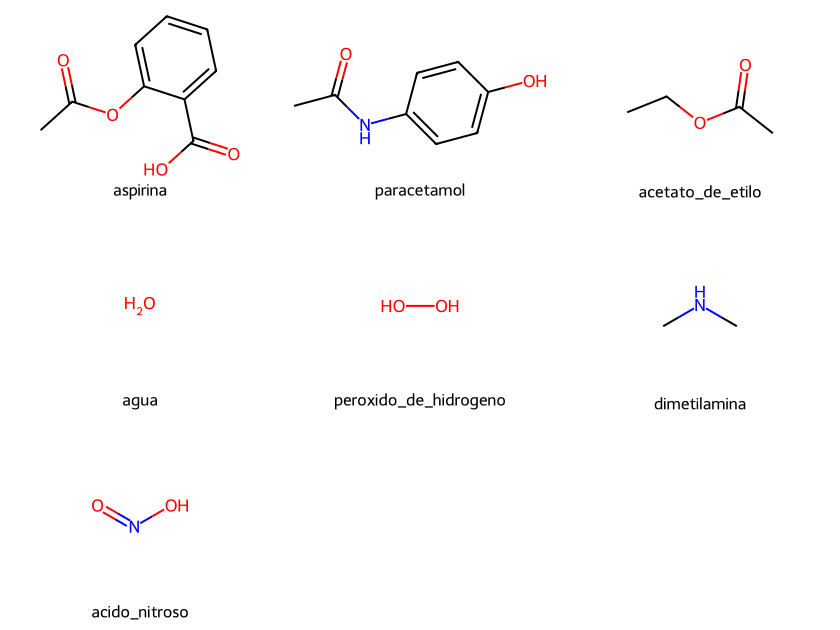

In [4]:
input_rows = []
for name, smiles in canonical_mixture.items():
    mol = mol_from_smiles(smiles)
    input_rows.append({
        "nombre": name, "smiles": smiles,
        "formula": rdMolDescriptors.CalcMolFormula(mol),
        "MW_g_mol": Descriptors.MolWt(mol),
        "carga": Chem.GetFormalCharge(mol),
        "fragmentos": len(Chem.GetMolFrags(mol)),
    })
inputs_df = pd.DataFrame(input_rows)
display(inputs_df)
input_grid = Draw.MolsToGridImage(
    [mol_from_smiles(s) for s in canonical_mixture.values()],
    legends=list(canonical_mixture), molsPerRow=3, subImgSize=(280, 210), useSVG=True,
)
display(SVG(getattr(input_grid, "data", input_grid)))
inputs_df.to_csv(OUTPUT_DIR / "componentes.csv", index=False)

## 4. Reglas SMARTS y ventanas de aplicación

| Regla | Transformación del ejemplo | Ventana demostrativa |
|---|---|---|
| `demo_ester_hydrolysis` | Éster + agua → ácido carboxílico + alcohol/fenol | Estrés ácido, pH ≤5 |
| `demo_amide_hydrolysis` | Amida + agua → ácido carboxílico + amina | Estrés ácido, pH ≤2, T ≥80 °C, duración ≥12 h |
| `demo_alcohol_oxidation` | Alcohol primario + H₂O₂ → aldehído + 2 H₂O | Estrés oxidativo |
| `demo_secondary_nitrosation` | Amina secundaria + HNO₂ → N-nitrosamina + H₂O | Estrés nitrosante, pH ≤5 |

Estos umbrales seleccionan reglas; no son fronteras cinéticas universales. La regla de
oxidación no representa catalizadores, selectividad ni competencia de vías. La hidrólisis
mantiene formas neutras para inspección estructural; no resuelve especiación de productos.

In [5]:
demo_rules = [
    Rule(
        id="demo_ester_hydrolysis", name="Hidrólisis de éster (demo)",
        reaction_smarts="[C:1](=[O:2])[O:3][#6:4].[OH2:5]>>[C:1](=[O:2])[OH:5].[OH:3][#6:4]",
        when=ConditionWindow(stresses=frozenset({StressType.ACID}), ph_max=5),
        priority=30, source="SMARTS demostrativa escrita para este notebook",
        tags=frozenset({"demo", "hydrolysis", "ester"}),
        metadata={"validated_experimentally": False},
    ),
    Rule(
        id="demo_amide_hydrolysis", name="Hidrólisis de amida (demo)",
        reaction_smarts="[C:1](=[O:2])[N;H1;+0:3][#6:4].[OH2:5]>>[C:1](=[O:2])[OH:5].[NH2:3][#6:4]",
        when=ConditionWindow(stresses=frozenset({StressType.ACID}), ph_max=2,
                             temperature_min_c=80, duration_min_h=12),
        priority=20, source="SMARTS demostrativa escrita para este notebook",
        tags=frozenset({"demo", "hydrolysis", "amide"}),
        metadata={"validated_experimentally": False},
    ),
    Rule(
        id="demo_alcohol_oxidation", name="Oxidación de alcohol primario (demo)",
        reaction_smarts="[CH2:1][OH:2].[OH:3][OH:4]>>[CH:1]=[O:2].[OH2:3].[OH2:4]",
        when=ConditionWindow(stresses=frozenset({StressType.OXIDATION})),
        priority=10, source="SMARTS demostrativa escrita para este notebook",
        tags=frozenset({"demo", "oxidation"}),
        metadata={"validated_experimentally": False},
    ),
    Rule(
        id="demo_secondary_nitrosation", name="Nitrosación secundaria (demo)",
        reaction_smarts="[N;H1;X3;+0;!$(N-[#6]=[!#6]):1]([#6:2])[#6:3].[OH:4][N:5]=[O:6]>>[N:1]([#6:2])([#6:3])[N:5]=[O:6].[OH2:4]",
        when=ConditionWindow(stresses=frozenset({StressType.NITROSATION}), ph_max=5),
        priority=5, source="SMARTS demostrativa escrita para este notebook",
        tags=frozenset({"demo", "nitrosation"}),
        metadata={"validated_experimentally": False,
                  "scope": "neutral secondary non-amide amine example; not a universal nitrosation rule"},
    ),
]
registry = RuleRegistry.from_json(RULES_JSON) if RULES_JSON is not None else RuleRegistry(demo_rules)
engine = DegradationEngine(registry)
registry.to_json(OUTPUT_DIR / "reglas_utilizadas.json")
rule_rows = []
for rule in registry:
    rxn = rdChemReactions.ReactionFromSmarts(rule.reaction_smarts)
    assert rxn is not None, rule.id
    rule_rows.append({"id": rule.id, "nombre": rule.name,
                      "reactivos": rxn.GetNumReactantTemplates(),
                      "productos": rxn.GetNumProductTemplates(),
                      "priority": rule.priority, "source": rule.source,
                      "SMARTS": rule.reaction_smarts})
rules_df = pd.DataFrame(rule_rows)
display(rules_df)

,id,nombre,reactivos,productos,priority,source,SMARTS
0,demo_ester_hydrolysis,Hidrólisis de éster (demo),2,2,30,SMARTS demostrativa escrita para este notebook,[C:1](=[O:2])[O:3][#6:4].[OH2:5]>>[C:1](=[O:2])[OH:5].[OH:3][#6:4]
1,demo_amide_hydrolysis,Hidrólisis de amida (demo),2,2,20,SMARTS demostrativa escrita para este notebook,[C:1](=[O:2])[N;H1;+0:3][#6:4].[OH2:5]>>[C:1](=[O:2])[OH:5].[NH2:3][#6:4]
2,demo_alcohol_oxidation,Oxidación de alcohol primario (demo),2,3,10,SMARTS demostrativa escrita para este notebook,[CH2:1][OH:2].[OH:3][OH:4]>>[CH:1]=[O:2].[OH2:3].[OH2:4]
3,demo_secondary_nitrosation,Nitrosación secundaria (demo),2,2,5,SMARTS demostrativa escrita para este notebook,[N;H1;X3;+0;!$(N-[#6]=[!#6]):1]([#6:2])[#6:3].[OH:4][N:5]=[O:6]>>[N:1]([#6:2])([#...


## 5. Reacción aislada y control conocido
La hidrólisis del acetato de etilo debe generar ácido acético y etanol con esta regla.
Este control verifica implementación y producto estructural, no una velocidad experimental.

,productos
0,CC(=O)O + CCO


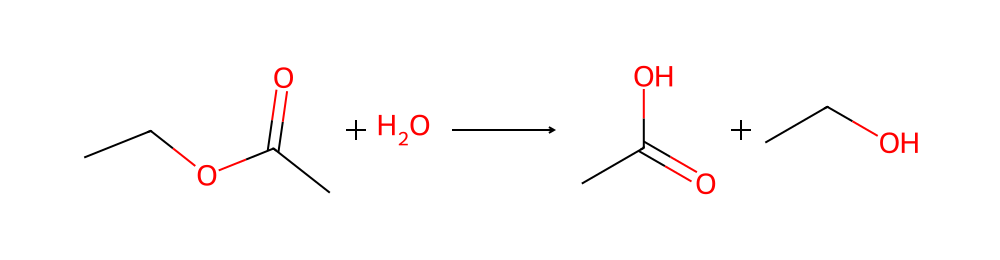

In [6]:
ester_rule = next(rule for rule in demo_rules if rule.id == "demo_ester_hydrolysis")
isolated_outcomes = apply_reaction(ester_rule.reaction_smarts, ["CCOC(C)=O", "O"])
display(pd.DataFrame({"productos": [" + ".join(p) for p in isolated_outcomes]}))
expected = {canonicalize_smiles("CC(=O)O"), canonicalize_smiles("CCO")}
assert any(set(products) == expected for products in isolated_outcomes)
reaction_example = "CCOC(C)=O.O>>" + ".".join(isolated_outcomes[0])
display(SVG(reaction_svg(reaction_example, width=1000, height=260)))

## 6. Mezcla completa y rutas hasta profundidad 3
Cada paso conserva **todos** los reactivos y productos. Los productos entran al pool en
la siguiente ronda. No se consumen reactivos ni se modelan concentraciones; una misma
especie puede ocupar varios slots. Se expanden también coproductos.

In [7]:
conditions = SCENARIOS[SCENARIO_TO_INSPECT]
network = engine.predict_mixture(canonical_mixture, conditions, **NETWORK_LIMITS)
steps_df = pd.DataFrame(network.to_rows())
print("Escenario:", SCENARIO_TO_INSPECT)
print("Especies:", len(network.species_depth), "Pasos:", len(network.steps))
print("Truncado:", network.truncated, "Advertencias:", network.warnings)
if not steps_df.empty:
    display(steps_df[["depth", "rule_id", "reactants", "products", "priority", "source"]])
else:
    print("No hay productos para estas reglas y condiciones; no implica estabilidad experimental.")
assert not network.truncated, "Aumentar límites o interpretar la búsqueda como parcial"

Escenario: acido_oxidante_nitrosante
Especies: 12 Pasos: 4
Truncado: False Advertencias: []


,depth,rule_id,reactants,products,priority,source
0,1,demo_ester_hydrolysis,CC(=O)Oc1ccccc1C(=O)O.O,CC(=O)O.O=C(O)c1ccccc1O,30,SMARTS demostrativa escrita para este notebook
1,1,demo_ester_hydrolysis,CCOC(C)=O.O,CC(=O)O.CCO,30,SMARTS demostrativa escrita para este notebook
2,1,demo_secondary_nitrosation,CNC.O=NO,CN(C)N=O.O,5,SMARTS demostrativa escrita para este notebook
3,2,demo_alcohol_oxidation,CCO.OO,CC=O.O.O,10,SMARTS demostrativa escrita para este notebook


## 7. Productos únicos, propiedades y estructuras
El mismo producto puede provenir de varias vías. Se conserva esa información en `steps_df`.
`profundidad_minima` es la primera ronda en la que apareció, no el tiempo de formación.

,id,nombre,smiles,profundidad_minima,es_entrada,formula,MW_g_mol,carga
7,M7,acido_acetico,CC(=O)O,1,False,C2H4O2,60.052,0
8,M8,acido_salicilico,O=C(O)c1ccccc1O,1,False,C7H6O3,138.122,0
9,M9,etanol,CCO,1,False,C2H6O,46.069,0
10,M10,NDMA,CN(C)N=O,1,False,C2H6N2O,74.083,0
11,M11,acetaldehido,CC=O,2,False,C2H4O,44.053,0


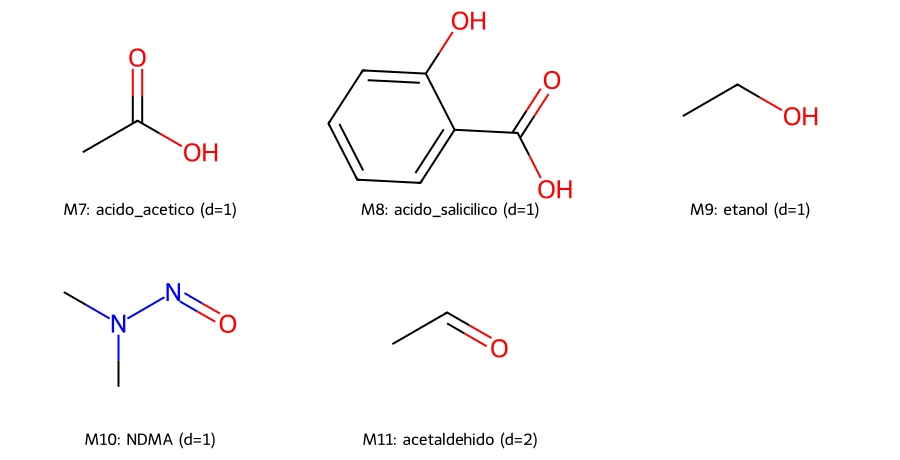

In [8]:
input_species = set(canonical_mixture.values())
known_names = {canonicalize_smiles(s): name for name, s in {
    "acido_acetico": "CC(=O)O", "etanol": "CCO", "acetaldehido": "CC=O",
    "acido_salicilico": "O=C(O)c1ccccc1O", "p_aminofenol": "Nc1ccc(O)cc1",
    "NDMA": "CN(C)N=O",
}.items()}
aliases = {smiles: "/".join(name for name, s in canonical_mixture.items() if s == smiles)
           for smiles in input_species}
aliases.update({s: name for s, name in known_names.items() if s not in aliases})
species_rows = []
for i, (smiles, depth) in enumerate(network.species_depth.items()):
    mol = mol_from_smiles(smiles)
    species_rows.append({"id": f"M{i}", "nombre": aliases.get(smiles, f"producto_{i}"),
                         "smiles": smiles, "profundidad_minima": depth,
                         "es_entrada": smiles in input_species,
                         "formula": rdMolDescriptors.CalcMolFormula(mol),
                         "MW_g_mol": Descriptors.MolWt(mol), "carga": Chem.GetFormalCharge(mol)})
species_df = pd.DataFrame(species_rows)
products_df = species_df.loc[~species_df["es_entrada"]].copy()
display(products_df)
if not products_df.empty:
    preview = products_df.head(MAX_STRUCTURES_TO_DRAW)
    product_grid = Draw.MolsToGridImage(
        [mol_from_smiles(s) for s in preview.smiles],
        legends=[f"{row.id}: {row.nombre} (d={row.profundidad_minima})" for row in preview.itertuples()],
        molsPerRow=3, subImgSize=(300, 230), useSVG=True,
    )
    product_grid_svg = getattr(product_grid, "data", product_grid)
    display(SVG(product_grid_svg))
    (OUTPUT_DIR / "productos.svg").write_text(product_grid_svg, encoding="utf-8")

## 8. Balance elemental y de carga
Se cuentan hidrógenos explícitos e implícitos en cada molécula. Un balance correcto es una
condición necesaria, pero no demuestra factibilidad, mecanismo ni selectividad. Una regla
que omite correaccionantes puede fallar este control aunque genere una estructura sanitizable.

In [9]:
def atomic_inventory(smiles_list):
    elements = Counter()
    charge = 0
    for smiles in smiles_list:
        mol = Chem.AddHs(mol_from_smiles(smiles))
        elements.update(atom.GetSymbol() for atom in mol.GetAtoms())
        charge += Chem.GetFormalCharge(mol)
    return elements, charge

balance_rows = []
for i, step in enumerate(network.steps):
    before, q_before = atomic_inventory(step.reactants)
    after, q_after = atomic_inventory(step.products)
    delta = {element: after[element] - before[element]
             for element in sorted(set(before) | set(after)) if after[element] != before[element]}
    balance_rows.append({"paso": f"R{i}", "regla": step.rule_id,
                         "delta_elementos": delta, "delta_carga": q_after - q_before,
                         "balanceado": not delta and q_after == q_before})
balance_df = pd.DataFrame(balance_rows, columns=["paso", "regla", "delta_elementos", "delta_carga", "balanceado"])
display(balance_df)
if RULES_JSON is None and not balance_df.empty:
    assert balance_df.balanceado.all(), "Error en una regla demostrativa"

,paso,regla,delta_elementos,delta_carga,balanceado
0,R0,demo_ester_hydrolysis,{},0,True
1,R1,demo_ester_hydrolysis,{},0,True
2,R2,demo_secondary_nitrosation,{},0,True
3,R3,demo_alcohol_oxidation,{},0,True


## 9. Visualización de cada transformación
Se dibujan reactivos y coproductos juntos. Las representaciones generadas por la red no
conservan un mapeo completo de átomos; no inferir centros de reacción de estos SMILES sin mapear.

**R0 · profundidad 1 · Hidrólisis de éster (demo)**

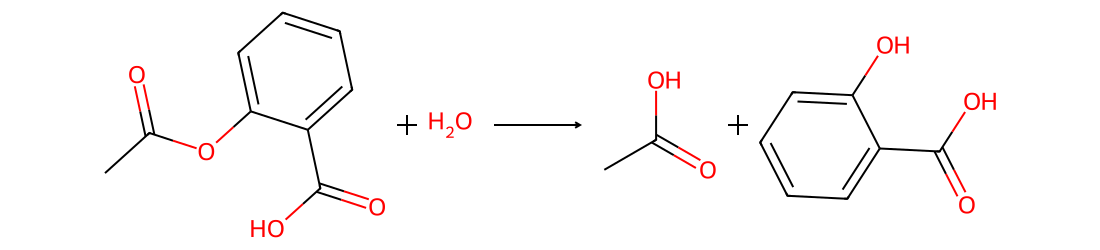

**R1 · profundidad 1 · Hidrólisis de éster (demo)**

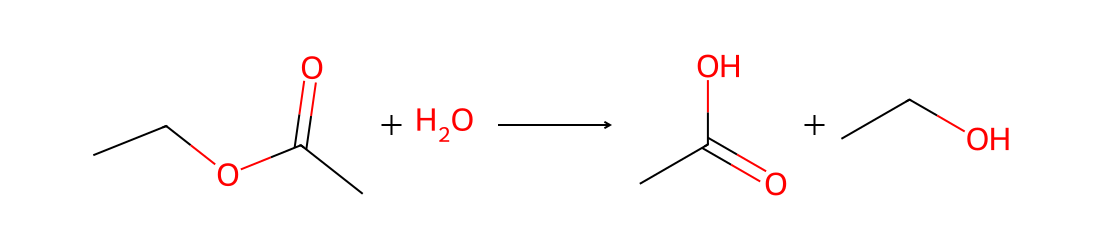

**R2 · profundidad 1 · Nitrosación secundaria (demo)**

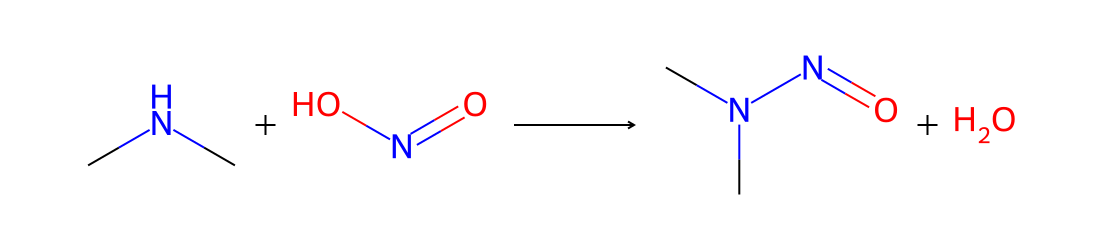

**R3 · profundidad 2 · Oxidación de alcohol primario (demo)**

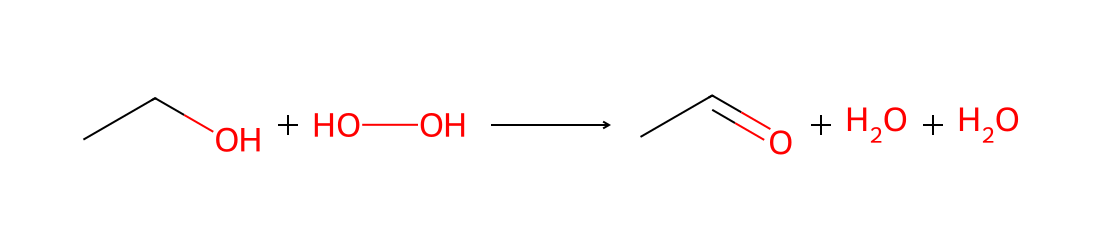

In [10]:
for i, step in enumerate(network.steps[:12]):
    rsmi = ".".join(step.reactants) + ">>" + ".".join(step.products)
    svg = reaction_svg(rsmi, width=1100, height=250)
    display(Markdown(f"**R{i} · profundidad {step.depth} · {step.rule_name}**"))
    display(SVG(svg))
    (OUTPUT_DIR / f"reaccion_R{i}.svg").write_text(svg, encoding="utf-8")

## 10. Centro de reacción con un mapeo explícito
El siguiente ejemplo tiene un mapeo manual conservado. No depende de RXNMapper ni de
Transformers y permite inspeccionar enlaces rotos/formados sin errores de compatibilidad.

,atom_map_1,atom_map_2,reactant_order,product_order
0,2,4,1.0,0.0
1,2,7,0.0,1.0


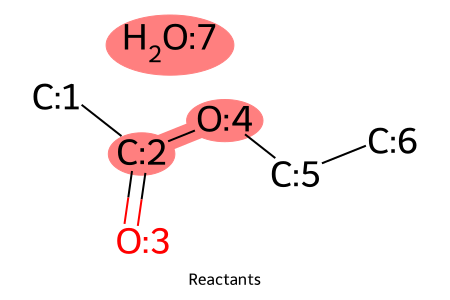

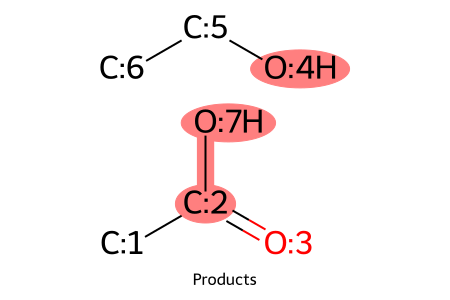

In [11]:
mapped_reaction = (
    "[CH3:1][C:2](=[O:3])[O:4][CH2:5][CH3:6].[OH2:7]>>"
    "[CH3:1][C:2](=[O:3])[OH:7].[OH:4][CH2:5][CH3:6]"
)
center = draw_reaction_center(mapped_reaction)
display(pd.DataFrame([asdict(change) for change in center.changed_bonds]))
display(SVG(center.reactants_svg))
display(SVG(center.products_svg))
(OUTPUT_DIR / "centro_reactivos.svg").write_text(center.reactants_svg, encoding="utf-8")
(OUTPUT_DIR / "centro_productos.svg").write_text(center.products_svg, encoding="utf-8")
assert len(center.changed_bonds) == 2

## 11. Red bipartita
Círculos = especies; cuadrados = pasos. Esta estructura conserva la necesidad conjunta
 de correaccionantes. Una flecha molécula→paso no representa por sí sola una vía suficiente.
El grafo guarda aristas separadas por slot para no perder coproductos idénticos.

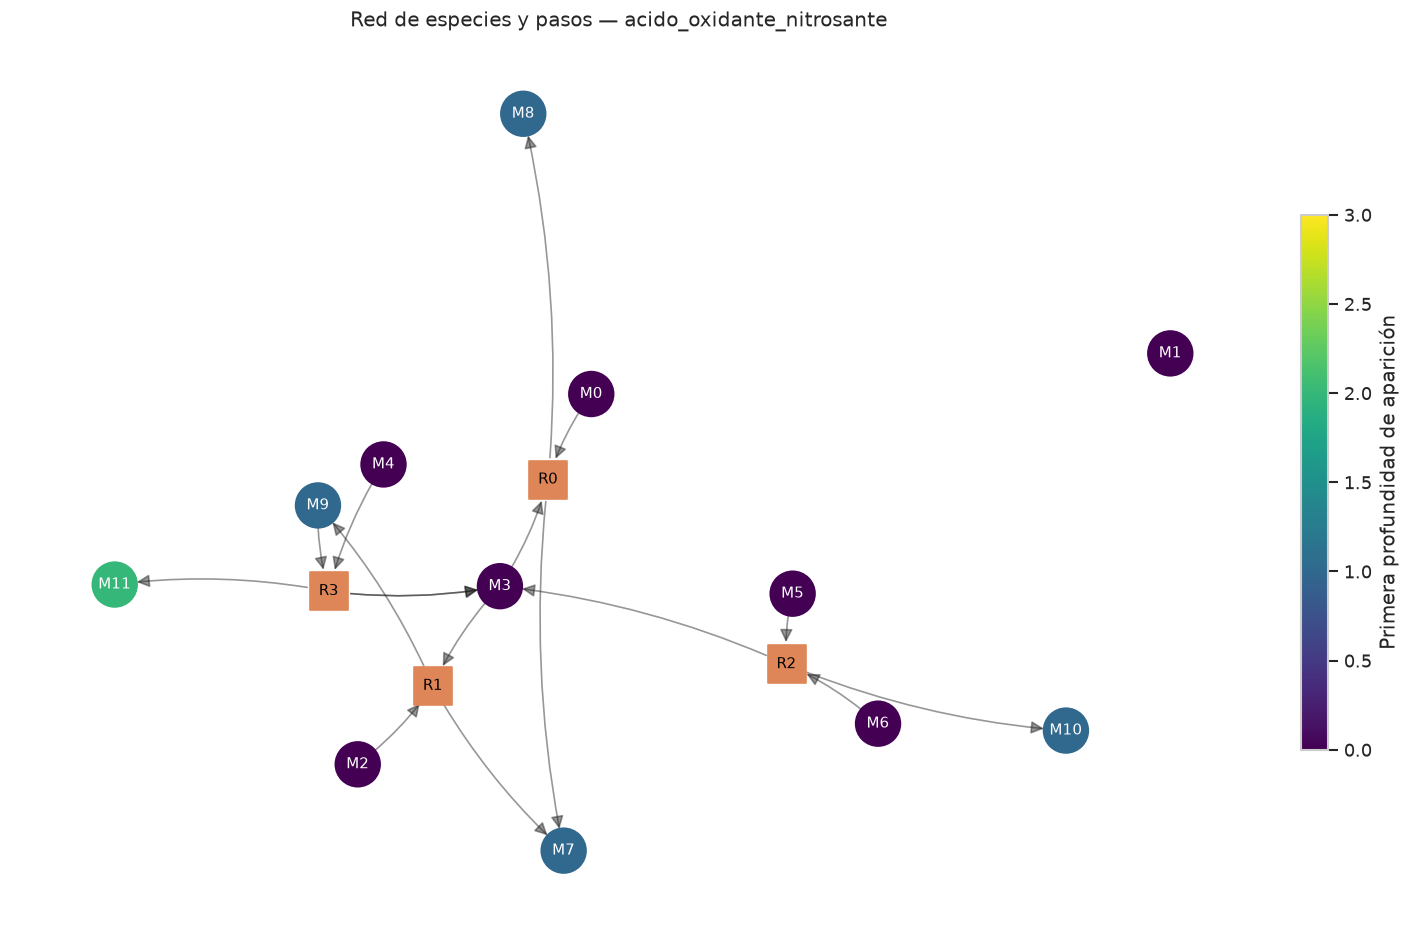

,id,nombre,smiles,profundidad_minima
0,M0,aspirina,CC(=O)Oc1ccccc1C(=O)O,0
1,M1,paracetamol,CC(=O)Nc1ccc(O)cc1,0
2,M2,acetato_de_etilo,CCOC(C)=O,0
3,M3,agua,O,0
4,M4,peroxido_de_hidrogeno,OO,0
5,M5,dimetilamina,CNC,0
6,M6,acido_nitroso,O=NO,0
7,M7,acido_acetico,CC(=O)O,1
8,M8,acido_salicilico,O=C(O)c1ccccc1O,1
9,M9,etanol,CCO,1


In [12]:
graph_payload = network.to_graph_dict()
G = nx.MultiDiGraph()
for node in graph_payload["nodes"]:
    G.add_node(node["id"], **{k: v for k, v in node.items() if k != "id"})
for edge in graph_payload["edges"]:
    G.add_edge(edge["source"], edge["target"], slot=edge["slot"])

pos = nx.spring_layout(G, seed=SEED, k=1.1, iterations=150)
molecule_nodes = [n for n, data in G.nodes(data=True) if data["kind"] == "molecule"]
reaction_nodes = [n for n, data in G.nodes(data=True) if data["kind"] == "reaction"]
fig, ax = plt.subplots(figsize=(13, 8))
nx.draw_networkx_edges(G, pos, ax=ax, arrows=True, arrowsize=16, alpha=0.45,
                       connectionstyle="arc3,rad=0.08", node_size=700)
nx.draw_networkx_nodes(G, pos, nodelist=molecule_nodes, ax=ax, node_size=720,
                       node_color=[G.nodes[n]["depth"] for n in molecule_nodes],
                       cmap=plt.colormaps["viridis"], vmin=0, vmax=NETWORK_LIMITS["max_depth"])
nx.draw_networkx_nodes(G, pos, nodelist=reaction_nodes, ax=ax, node_shape="s",
                       node_size=500, node_color="#df8658")
nx.draw_networkx_labels(G, pos, ax=ax, font_size=9,
                       labels={n: n.upper() for n in molecule_nodes}, font_color="white")
nx.draw_networkx_labels(G, pos, ax=ax, font_size=9,
                       labels={n: n.upper() for n in reaction_nodes}, font_color="black")
color_scale = plt.cm.ScalarMappable(norm=plt.Normalize(0, NETWORK_LIMITS["max_depth"]),
                                   cmap=plt.colormaps["viridis"])
fig.colorbar(color_scale, ax=ax, shrink=0.6, label="Primera profundidad de aparición")
ax.set_title(f"Red de especies y pasos — {SCENARIO_TO_INSPECT}")
ax.axis("off")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "red_reacciones.png", bbox_inches="tight")
fig.savefig(OUTPUT_DIR / "red_reacciones.svg", bbox_inches="tight")
plt.show()
display(species_df[["id", "nombre", "smiles", "profundidad_minima"]])

## 12. Comparación de escenarios
Se conserva la misma mezcla y las mismas reglas. Cambian solo las condiciones.
Los conteos expresan **alcance de la enumeración**, no cantidad de degradación ni riesgo.

,escenario,pasos,productos_nuevos,profundidad_observada,truncado,advertencias
0,control,0,0,0,False,
1,acido,2,3,1,False,
2,acido_oxidante_nitrosante,4,5,2,False,
3,acido_caliente,5,6,2,False,


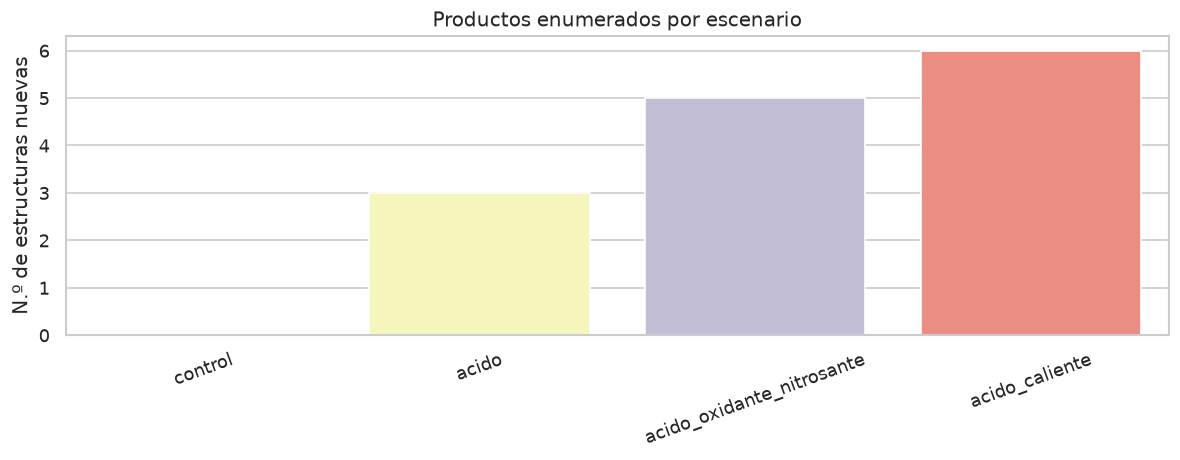

In [13]:
scenario_networks = compare_scenarios(registry, canonical_mixture, SCENARIOS, **NETWORK_LIMITS)
summary_rows = []
all_steps = []
for scenario, result in scenario_networks.items():
    unique_products = set(result.species_depth) - input_species
    summary_rows.append({"escenario": scenario, "pasos": len(result.steps),
                         "productos_nuevos": len(unique_products),
                         "profundidad_observada": max(result.species_depth.values(), default=0),
                         "truncado": result.truncated, "advertencias": "; ".join(result.warnings)})
    for step in result.steps:
        all_steps.append({"escenario": scenario, **asdict(step)})
summary_df = pd.DataFrame(summary_rows)
display(summary_df)
fig, ax = plt.subplots(figsize=(10, 4))
sns.barplot(data=summary_df, x="escenario", y="productos_nuevos", hue="escenario",
            palette="Set3", legend=False, ax=ax)
ax.set(xlabel="", ylabel="N.º de estructuras nuevas", title="Productos enumerados por escenario")
ax.tick_params(axis="x", rotation=20)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "comparacion_escenarios.png", bbox_inches="tight")
plt.show()

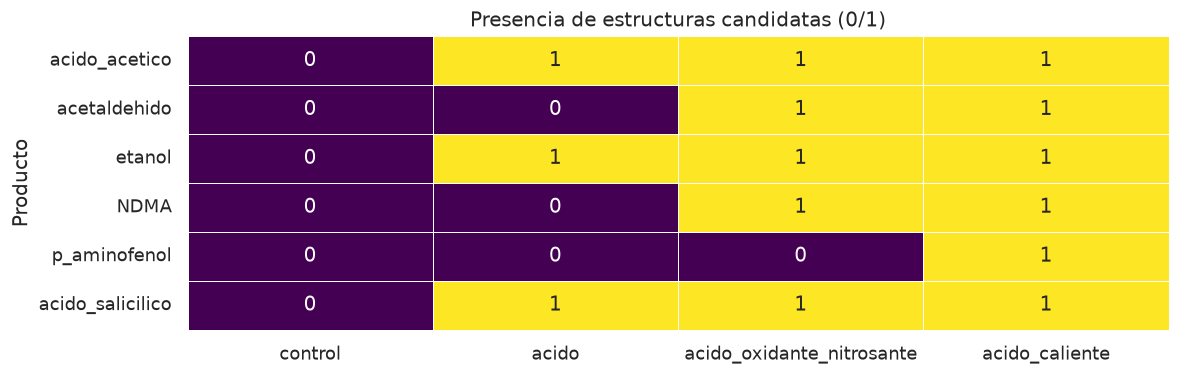

In [14]:
all_new_species = sorted(set().union(*(set(n.species_depth) - input_species for n in scenario_networks.values())))
presence_df = pd.DataFrame({
    name: [int(s in n.species_depth) for s in all_new_species]
    for name, n in scenario_networks.items()
}, index=[aliases.get(s, s) for s in all_new_species])
if not presence_df.empty:
    fig, ax = plt.subplots(figsize=(10, max(3, 0.55 * len(presence_df))))
    sns.heatmap(presence_df, annot=True, fmt="d", cmap="viridis", vmin=0, vmax=1,
                cbar=False, linewidths=0.5, ax=ax)
    ax.set(xlabel="", ylabel="Producto", title="Presencia de estructuras candidatas (0/1)")
    fig.tight_layout()
    fig.savefig(OUTPUT_DIR / "presencia_productos.png", bbox_inches="tight")
    plt.show()
else:
    print("Sin productos nuevos para comparar.")

## 13. Controles de falsación del ejemplo
Retirar agua debe suprimir las hidrólisis de estas reglas; retirar el agente nitrosante
suprime la nitrosación de la red. Se comprueba también la recuperación de los productos
esperados. Estos controles prueban la lógica del ejemplo, no sensibilidad experimental.

In [15]:
if RULES_JSON is None:
    without_water = {name: s for name, s in canonical_mixture.items() if s != canonicalize_smiles("O")}
    no_water_result = engine.predict_mixture(without_water, SCENARIOS["acido"], **NETWORK_LIMITS)
    assert not any("hydrolysis" in step.rule_id for step in no_water_result.steps)
    without_nitrosating = {name: s for name, s in canonical_mixture.items() if s != canonicalize_smiles("O=NO")}
    no_nitroso_result = engine.predict_mixture(without_nitrosating, conditions, **NETWORK_LIMITS)
    assert not any(step.rule_id == "demo_secondary_nitrosation" for step in no_nitroso_result.steps)
    assert not scenario_networks["control"].steps
    if MIXTURE == {
        "aspirina": "CC(=O)Oc1ccccc1C(=O)O", "paracetamol": "CC(=O)Nc1ccc(O)cc1",
        "acetato_de_etilo": "CCOC(C)=O", "agua": "O", "peroxido_de_hidrogeno": "OO",
        "dimetilamina": "CNC", "acido_nitroso": "O=NO",
    }:
        assert canonicalize_smiles("O=C(O)c1ccccc1O") in scenario_networks["acido"].species_depth
        assert canonicalize_smiles("CN(C)N=O") in scenario_networks["acido_oxidante_nitrosante"].species_depth
        assert canonicalize_smiles("CC=O") in scenario_networks["acido_oxidante_nitrosante"].species_depth
        assert canonicalize_smiles("Nc1ccc(O)cc1") in scenario_networks["acido_caliente"].species_depth
    print("Controles del ejemplo: OK")
else:
    print("Biblioteca propia: definir controles positivos/negativos específicos para esas reglas.")

Controles del ejemplo: OK


## 14. Cobertura estructural de las reacciones
Referencias = hidrólisis de tres ésteres diferentes del ejemplo principal. Se generan con
la misma regla demostrativa; **no son un dataset de entrenamiento**. Se busca mostrar los
vecinos y detectar extrapolación estructural. El umbral es configurable, no calibrado.
El fingerprint no representa pH, concentración, tiempo, catalizador ni escala.

,paso,regla,similaridad_maxima,dentro_umbral,referencia_cercana,reaccion
0,R0,demo_ester_hydrolysis,0.300000,False,COC(C)=O.O>>CC(=O)O.CO,CC(=O)Oc1ccccc1C(=O)O.O>>CC(=O)O.O=C(O)c1ccccc1O
1,R1,demo_ester_hydrolysis,0.647059,True,CCCOC(C)=O.O>>CC(=O)O.CCCO,CCOC(C)=O.O>>CC(=O)O.CCO
2,R2,demo_secondary_nitrosation,0.181818,False,COC(C)=O.O>>CC(=O)O.CO,CNC.O=NO>>CN(C)N=O.O
3,R3,demo_alcohol_oxidation,0.166667,False,CCOC(=O)CC.O>>CCC(=O)O.CCO,CCO.OO>>CC=O.O.O


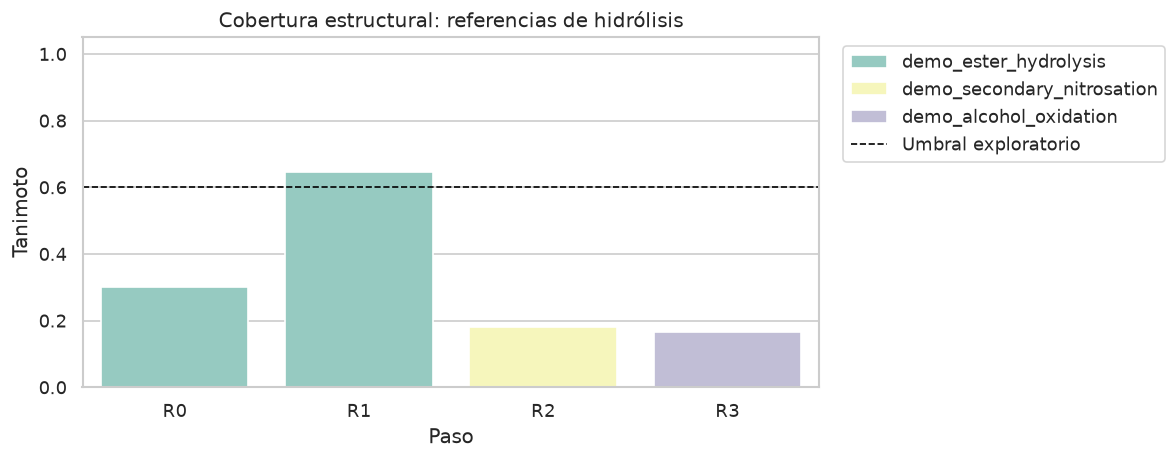

In [16]:
reference_reactions = []
for ester in ["CC(=O)OC", "CCC(=O)OCC", "CC(=O)OCCC"]:
    products = apply_reaction(ester_rule.reaction_smarts, [ester, "O"])[0]
    reference_reactions.append(canonicalize_smiles(ester) + ".O>>" + ".".join(products))
domain = SimilarityDomain(reference_reactions, mode="reaction", threshold=0.6, radius=2, n_bits=2048)
coverage_rows = []
for i, step in enumerate(network.steps):
    rsmi = ".".join(step.reactants) + ">>" + ".".join(step.products)
    assessment = domain.assess(rsmi, k=3)
    coverage_rows.append({"paso": f"R{i}", "regla": step.rule_id,
                          "similaridad_maxima": assessment.nearest_similarity,
                          "dentro_umbral": assessment.in_domain,
                          "referencia_cercana": assessment.neighbors[0].reference,
                          "reaccion": rsmi})
coverage_df = pd.DataFrame(coverage_rows)
display(coverage_df)
if not coverage_df.empty:
    fig, ax = plt.subplots(figsize=(10, 4))
    sns.barplot(data=coverage_df, x="paso", y="similaridad_maxima", hue="regla", palette="Set3", ax=ax)
    ax.axhline(domain.threshold, linestyle="--", color="black", linewidth=1, label="Umbral exploratorio")
    ax.set(ylim=(0, 1.05), ylabel="Tanimoto", xlabel="Paso", title="Cobertura estructural: referencias de hidrólisis")
    ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
    fig.tight_layout()
    fig.savefig(OUTPUT_DIR / "cobertura_estructural.png", bbox_inches="tight")
    plt.show()

## 15. Nitrosación: sitio, contexto y producto directo
Este bloque usa el módulo específico de nitrosaminas y conserva la distinción entre
presencia de precursor, fuente nitrosante y producto estructural. No calcula probabilidad
de formación. No aplicar la función de nitrosación secundaria a nitrosamidas o rutas de
aminas terciarias como si fueran equivalentes.

Flags: ('amine_precursor_present', 'nitrosating_source_present', 'acidic_conditions', 'excipient_nitrite_level_provided', 'fda_root_cause_combination_present')
Productos directos: ['CN(C)N=O']


,nitrogen_index,kind,carbon_neighbor_indices,methyl_substituent_count,total_hydrogens,aromatic,amide_like
0,1,secondary_amine,"(0, 2)",2,1,False,False


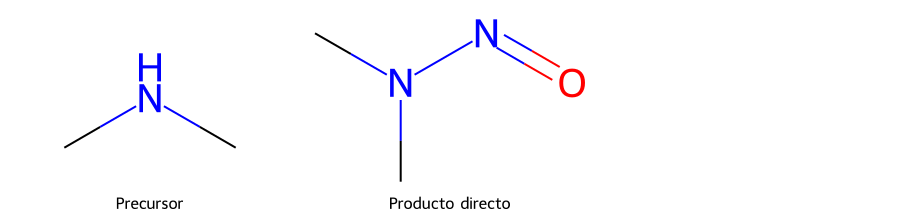

In [17]:
AMINE_SMILES = "CNC"  # Dimetilamina, ejemplo independiente y editable
context = NitrosationContext(nitrite_present=True, ph=3.2, temperature_c=25,
                             excipient_nitrite_ppm=10)
nitrosation = assess_nitrosation_context(AMINE_SMILES, context)
direct_nitroso_products = enumerate_secondary_amine_nitrosation_products(AMINE_SMILES)
display(pd.DataFrame([asdict(center) for center in nitrosation.centers]))
print("Flags:", nitrosation.flags)
print("Productos directos:", direct_nitroso_products)
if direct_nitroso_products:
    nitroso_grid = Draw.MolsToGridImage(
        [mol_from_smiles(AMINE_SMILES)] + [mol_from_smiles(s) for s in direct_nitroso_products],
        legends=["Precursor"] + ["Producto directo" for _ in direct_nitroso_products],
        molsPerRow=3, subImgSize=(300, 220), useSVG=True,
    )
    display(SVG(getattr(nitroso_grid, "data", nitroso_grid)))

## 16. Especiación frente a pH
Los pKa son **entradas ilustrativas suministradas**, no predicciones del paquete.
Se calculan fracciones de HNO₂ y amina libre con equilibrio acuoso de un sitio y sin
correcciones de actividad. Estas curvas no son curvas de rendimiento ni una función de riesgo.

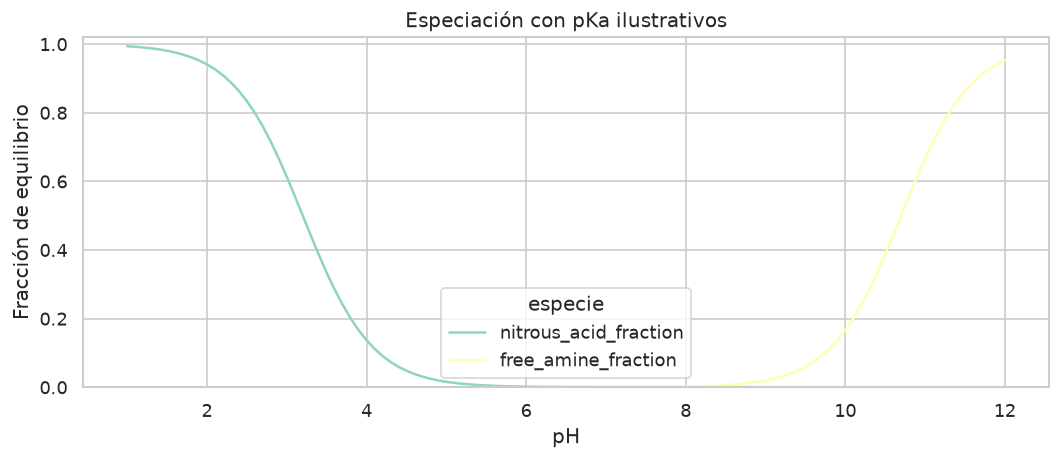

In [18]:
AMINE_PKA_EXAMPLE = 10.7
NITROUS_ACID_PKA_EXAMPLE = 3.2
speciation_df = pd.DataFrame([
    asdict(nitrosation_speciation(float(ph), amine_pka=AMINE_PKA_EXAMPLE,
                                 nitrous_acid_pka=NITROUS_ACID_PKA_EXAMPLE))
    for ph in np.linspace(1, 12, 111)
])
speciation_long = speciation_df.melt(id_vars="ph",
    value_vars=["nitrous_acid_fraction", "free_amine_fraction"], var_name="especie", value_name="fraccion")
fig, ax = plt.subplots(figsize=(9, 4))
sns.lineplot(data=speciation_long, x="ph", y="fraccion", hue="especie", palette="Set3", ax=ax)
ax.set(xlabel="pH", ylabel="Fracción de equilibrio", title="Especiación con pKa ilustrativos", ylim=(0, 1.02))
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "especiacion.png", bbox_inches="tight")
plt.show()

## 17. Cota de formación limitada por nitrito
`nitrite_ppm` expresa mg/kg de **ion NO₂⁻**, no NaNO₂. La masa de amina corresponde a la
estructura libre proporcionada. Se supone conversión completa a un producto mononitrosado,
sin otras fuentes nitrosantes. La salida es una cota estequiométrica, no el contenido esperado.
Los límites de productos posicionales comparten el mismo presupuesto y no se suman.

In [19]:
EXCIPIENT_MASS_MG = 100.0
NITRITE_PPM = 10.0
AMINE_MASS_MG = 100.0
nitrite_mass = excipient_nitrite_mass(excipient_mass_mg=EXCIPIENT_MASS_MG, nitrite_ppm=NITRITE_PPM)
budget = nitrite_limited_bound(AMINE_SMILES, amine_mass_mg=AMINE_MASS_MG, nitrite_mass_mg=nitrite_mass)
budget_df = pd.DataFrame([{"producto": s, "cota_mg": bound, "cota_ug": bound * 1000}
                          for s, bound in budget.product_bounds_mg.items()])
print("Nitrito disponible [mg de NO2-]:", nitrite_mass)
print("Supuestos:", budget.assumptions)
display(budget_df)

Nitrito disponible [mg de NO2-]: 0.001
Supuestos: ('one_nitrite_per_mononitroso_product', 'complete_conversion_upper_bound', 'positional_products_share_budget', 'no_other_nitrosating_sources')


,producto,cota_mg,cota_ug
0,CN(C)N=O,0.00161,1.610325


## 18. Exposición térmica: pérdida de precursor
Se usa primer orden con Arrhenius y parámetros **ilustrativos**. Sustituir `k_reference_per_h`
y `activation_energy_kj_mol` por valores medidos/ajustados para el compuesto y medio.
La conversión es desaparición del precursor; no distribuye masa entre productos de la red.

,integrated_rate,remaining_fraction,converted_fraction,stage_rate_constants_per_h
0,0.029256,0.971168,0.028832,"(0.001, 0.0026277803669048196)"


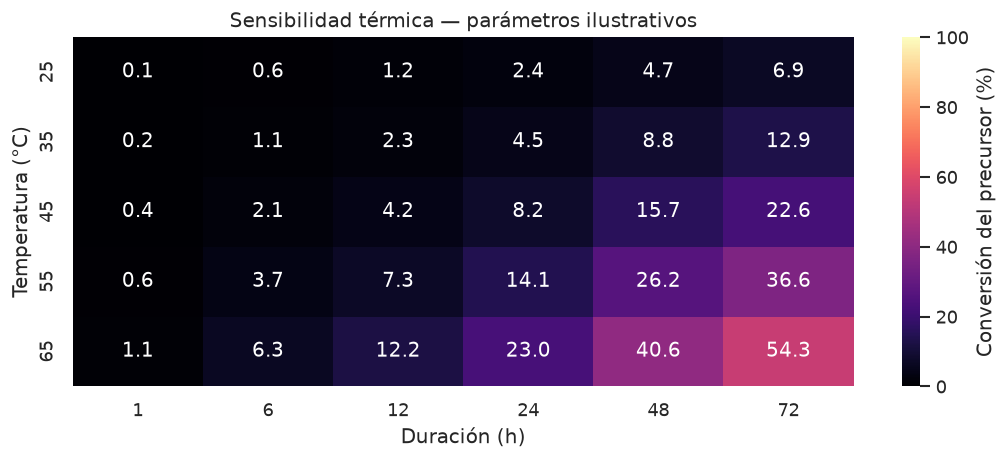

In [20]:
K_REFERENCE_PER_H = 0.001
REFERENCE_TEMPERATURE_C = 25.0
ACTIVATION_ENERGY_KJ_MOL = 50.0
thermal_stages = [ThermalStage(25, 24), ThermalStage(40, 2)]
thermal_loss = first_order_exposure(
    thermal_stages, k_reference_per_h=K_REFERENCE_PER_H,
    reference_temperature_c=REFERENCE_TEMPERATURE_C,
    activation_energy_kj_mol=ACTIVATION_ENERGY_KJ_MOL,
)
display(pd.DataFrame([asdict(thermal_loss)]))
kinetics_rows = []
for temperature in [25, 35, 45, 55, 65]:
    for duration in [1, 6, 12, 24, 48, 72]:
        value = first_order_exposure([ThermalStage(temperature, duration)],
            k_reference_per_h=K_REFERENCE_PER_H, reference_temperature_c=REFERENCE_TEMPERATURE_C,
            activation_energy_kj_mol=ACTIVATION_ENERGY_KJ_MOL)
        kinetics_rows.append({"temperatura_C": temperature, "duracion_h": duration,
                              "conversion_pct": value.converted_fraction * 100})
kinetics_df = pd.DataFrame(kinetics_rows)
fig, ax = plt.subplots(figsize=(9, 4))
sns.heatmap(kinetics_df.pivot(index="temperatura_C", columns="duracion_h", values="conversion_pct"),
            annot=True, fmt=".1f", cmap="magma", vmin=0, vmax=100,
            cbar_kws={"label": "Conversión del precursor (%)"}, ax=ax)
ax.set(title="Sensibilidad térmica — parámetros ilustrativos", xlabel="Duración (h)", ylabel="Temperatura (°C)")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "cinetica_termica.png", bbox_inches="tight")
plt.show()

## 19. SynKit opcional: grafo ITS
El cálculo principal funciona sin SynKit. Para activarlo en un entorno compatible:
```python
%pip install 'synkit>=1.6.2,<1.7'
```
Este bloque usa únicamente la reacción ya mapeada, no las salidas sin mapeo de la red.

In [21]:
try:
    synkit_version = version("synkit")
except PackageNotFoundError:
    synkit_version = None
if synkit_version is not None:
    from chem_predict.integrations import reaction_to_its
    its = reaction_to_its(mapped_reaction)
    display(pd.DataFrame(its.changes_to_dict()["changed_bonds"]))
else:
    print("SynKit no instalado. Bloque opcional omitido; el resto del notebook está completo.")

SynKit no instalado. Bloque opcional omitido; el resto del notebook está completo.


## 20. Rendimiento con un modelo externo, sin resultados ficticios
No se suministra un checkpoint entrenado. Por eso este bloque queda inactivo.
Para usar un modelo ya cargado de rxnfp/SimpleTransformers, asignarlo a `yield_model`.
Debe aceptar `predict(list[str])` y devolver `(predicciones, salidas_crudas)`.
La preparación/tokenización debe coincidir con el entrenamiento del modelo.

Las escalas son `percent`, `fraction` o `standardized`; esta última requiere media y
desvío **del entrenamiento del checkpoint**, en %. El modelo debe ser aplicable a las
reacciones evaluadas. La cobertura demostrativa de este notebook no lo valida.

In [22]:
yield_model = None
YIELD_MODEL_ID = ""  # Identificar checkpoint y versión
YIELD_OUTPUT_SCALE = "percent"
TRAINING_YIELD_MEAN = None
TRAINING_YIELD_STD = None

if yield_model is not None:
    options = {"model_id": YIELD_MODEL_ID, "output_scale": YIELD_OUTPUT_SCALE}
    if YIELD_OUTPUT_SCALE == "standardized":
        options.update(training_mean=TRAINING_YIELD_MEAN, training_std=TRAINING_YIELD_STD)
    yield_predictor = YieldPredictor.from_rxn_yields_model(yield_model, **options)
    candidate_reactions = [".".join(s.reactants) + ">>" + ".".join(s.products) for s in network.steps]
    yields_df = pd.DataFrame([asdict(result) for result in yield_predictor.predict(candidate_reactions)])
    display(yields_df)
    yields_df.to_json(OUTPUT_DIR / "rendimientos_modelo.json", orient="records", indent=2)
else:
    print("Sin checkpoint: no se calculan ni simulan rendimientos.")

Sin checkpoint: no se calculan ni simulan rendimientos.


## 21. Exportación y reproducibilidad
Se guardan estructuras, reglas, balances, pasos, cobertura, escenarios, figuras y un
manifiesto con versiones. JSON conserva metadatos; CSV permite trabajar con pandas.
La carpeta de salida es relativa al directorio de ejecución del notebook.

In [23]:
steps_df.to_csv(OUTPUT_DIR / "pasos.csv", index=False)
species_df.to_csv(OUTPUT_DIR / "especies.csv", index=False)
products_df.to_csv(OUTPUT_DIR / "productos.csv", index=False)
balance_df.to_json(OUTPUT_DIR / "balance_elemental.json", orient="records", indent=2)
summary_df.to_csv(OUTPUT_DIR / "resumen_escenarios.csv", index=False)
presence_df.to_csv(OUTPUT_DIR / "presencia_productos.csv")
coverage_df.to_csv(OUTPUT_DIR / "cobertura_estructural.csv", index=False)
speciation_df.to_csv(OUTPUT_DIR / "especiacion.csv", index=False)
budget_df.to_csv(OUTPUT_DIR / "cota_nitrito.csv", index=False)
kinetics_df.to_csv(OUTPUT_DIR / "cinetica_termica.csv", index=False)

for scenario, result in scenario_networks.items():
    (OUTPUT_DIR / f"red_{scenario}.json").write_text(
        json.dumps(result.to_dict(), ensure_ascii=False, indent=2), encoding="utf-8")
(OUTPUT_DIR / "grafo_bipartito.json").write_text(
    json.dumps(graph_payload, ensure_ascii=False, indent=2), encoding="utf-8")
manifest = {
    "chem_predict_commit": CHEM_PREDICT_REF, "python": platform.python_version(),
    "packages": packages, "seed": SEED, "mixture": canonical_mixture,
    "limits": NETWORK_LIMITS, "scenario_inspected": SCENARIO_TO_INSPECT,
    "rules_source": "demo" if RULES_JSON is None else str(RULES_JSON),
    "scope": "rule-based candidate enumeration; not calibrated yield/probability",
    "kinetic_parameters": {"k_reference_per_h": K_REFERENCE_PER_H,
                            "reference_temperature_c": REFERENCE_TEMPERATURE_C,
                            "activation_energy_kj_mol": ACTIVATION_ENERGY_KJ_MOL},
}
(OUTPUT_DIR / "manifest.json").write_text(json.dumps(manifest, ensure_ascii=False, indent=2), encoding="utf-8")
requirements = [CHEM_PREDICT_SPEC] + [f"{p}=={v}" for p, v in packages.items() if p != "chem-predict"]
(OUTPUT_DIR / "requirements_reproduccion.txt").write_text("\n".join(requirements) + "\n", encoding="utf-8")
display(pd.DataFrame([{"archivo": path.name, "bytes": path.stat().st_size}
                      for path in sorted(OUTPUT_DIR.iterdir()) if path.is_file()]))
print("Directorio:", OUTPUT_DIR.resolve())

Directorio: /workspace/scratch/96296bce70f5/deliverables/chem_predict_resultados


,archivo,bytes
0,balance_elemental.json,560
1,centro_productos.svg,14690
2,centro_reactivos.svg,16127
3,cinetica_termica.csv,769
4,cinetica_termica.png,92449
5,cobertura_estructural.csv,476
6,cobertura_estructural.png,60815
7,comparacion_escenarios.png,53959
8,componentes.csv,349
9,cota_nitrito.csv,75


## 22. Lectura de resultados y ampliación
- `pasos.csv`: vías y coproductos, sin agregarlos como si fueran productos independientes.
- `productos.csv`: estructuras nuevas deduplicadas; presencia no equivale a concentración.
- `red_*.json`: reglas, condiciones y límites usados en cada escenario.
- `balance_elemental.json`: identificar reglas incompletas o mal traducidas.
- `cobertura_estructural.csv`: proximidad estructural al panel de referencia; no confianza calibrada.

Para ampliar cálculos: sustituir la biblioteca SMARTS por reglas curadas, definir controles
positivos/negativos y compararlas con productos experimentales. Mantener ensayos y condiciones
asociados a cada observación. Las cantidades de nitrito, pKa y parámetros cinéticos pertenecen
a cálculos separados; el notebook no los transforma en probabilidades de los productos enumerados.

**Referencias de implementación:**
[Chem-Predict: guía de flujos](https://github.com/juanjosecas/Chem-Predict/blob/3ca742e8a7cd68e94a23cfe45677cb045eee1d38/docs/modular-workflows.md),
[RDKit: reacciones](https://www.rdkit.org/docs/source/rdkit.Chem.rdChemReactions.html),
[RDKit: fingerprints](https://www.rdkit.org/docs/source/rdkit.Chem.rdFingerprintGenerator.html),
[SynKit](https://github.com/TieuLongPhan/SynKit),
[rxn_yields](https://github.com/rxn4chemistry/rxn_yields).